In [15]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.svm import LinearSVC

In [16]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/creditcard.csv"
df = pd.read_csv(url)
df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
143895,85707.0,1.093335,-0.158927,1.370492,1.288310,-1.128427,-0.026385,-0.732962,0.286930,0.787882,...,-0.009683,0.085656,0.020884,0.502682,0.319047,-0.435057,0.061565,0.027804,9.99,0
96978,66028.0,-1.006817,1.457301,2.178954,1.320763,0.807246,-0.630207,1.311643,-0.373908,-1.344350,...,-0.461457,-1.449266,-0.110876,0.291435,0.087092,-0.618025,-0.424620,-0.142319,4.16,0
69122,53275.0,-2.675042,1.422996,-1.656531,0.676636,-8.818138,6.953468,2.309828,-11.334819,-1.060346,...,-5.532856,1.862382,0.220513,0.043896,1.262958,-0.207940,1.134348,-0.354042,1600.00,0
276018,166850.0,-1.778307,1.768186,-0.867005,-1.121539,0.754992,-0.627248,1.068994,-0.251531,1.286270,...,-0.622286,-0.706309,0.081464,-1.007183,-0.100495,0.099160,-0.365113,-0.573032,8.93,0
223116,143252.0,-1.709817,-0.838933,-0.187408,-1.883438,-1.866175,1.853458,1.418194,0.278569,-1.102382,...,-0.342085,-0.929772,-0.319478,-0.341594,0.497737,-0.427174,-0.054234,-0.389793,515.20,0


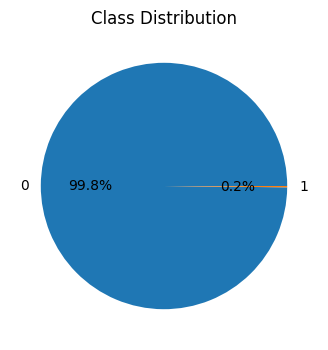

In [17]:
labels = df.Class.unique()
sizes = df.Class.value_counts().values

fig, ax = plt.subplots(figsize=(6, 4))
ax.pie(sizes, labels=labels, autopct='%1.1f%%')
ax.set_title('Class Distribution')
plt.show()

<Axes: >

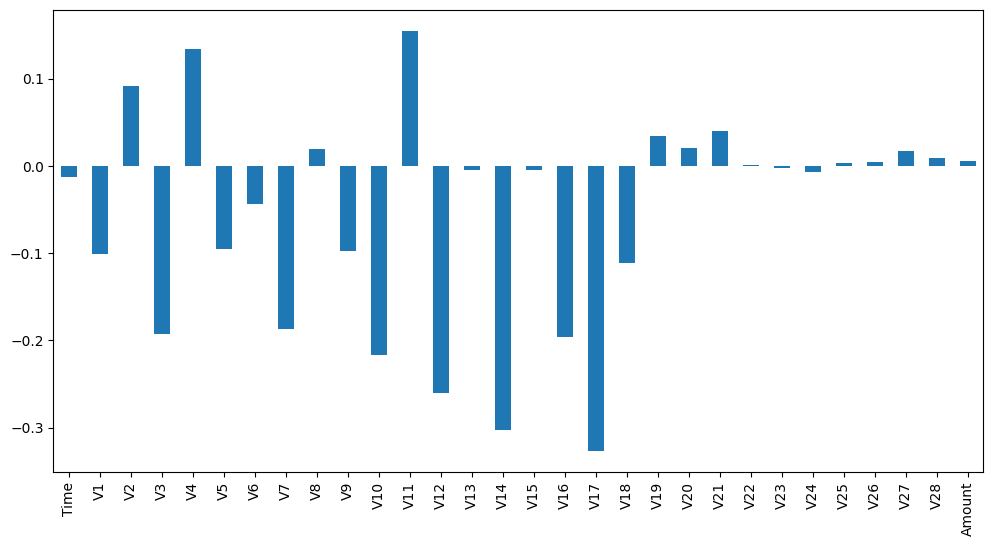

In [18]:
correlation_values = df.corr()['Class'].drop('Class')
correlation_values.plot(kind='bar', figsize=(12, 6))

In [19]:
df.iloc[:, 1:30] = StandardScaler().fit_transform(df.iloc[:, 1:30])
data_matrix = df.values

X = data_matrix[:, 1:30]
y = data_matrix[:, 30]

X = normalize(X, axis=0)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [34]:
w_train = compute_sample_weight(class_weight='balanced', y=y_train)

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train, sample_weight=w_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [35]:
svm = LinearSVC(class_weight='balanced', random_state=42)
svm.fit(X_train, y_train, sample_weight=w_train)

LinearSVC(class_weight='balanced', random_state=42)

In [36]:
y_pred_dt = dt.predict_proba(X_test)[:,1]

In [37]:
roc_auc_dt = roc_auc_score(y_test, y_pred_dt)
print('Decision Tree ROC-AUC score : {0:.3f}'.format(roc_auc_dt))

Decision Tree ROC-AUC score : 0.921


In [38]:
y_pred_svm = svm.decision_function(X_test)

In [39]:
roc_auc_svm = roc_auc_score(y_test, y_pred_svm)
print("SVM ROC-AUC score: {0:.3f}".format(roc_auc_svm))

SVM ROC-AUC score: 0.970


In [40]:
correlation_values = abs(df.corr()['Class']).drop('Class')
correlation_values = correlation_values.sort_values(ascending=False)[:6]
correlation_values

V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
Name: Class, dtype: float64

In [32]:
X = data_matrix[:,[3, 10, 12, 14, 16, 17]]
X = normalize(X, axis=0)